In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load data
master = pd.read_csv('../data/master_ipl.csv')
matches = pd.read_csv('../data/matches_clean.csv')
match_features = pd.read_csv('../data/match_features.csv')

master['date'] = pd.to_datetime(master['date'])
matches['date'] = pd.to_datetime(matches['date'])
match_features['date'] = pd.to_datetime(match_features['date'])

print("PyTorch imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Data loaded — Master: {master.shape}")

Using device: cpu
PyTorch imported successfully!
PyTorch version: 2.10.0+cpu
Data loaded — Master: (278205, 32)


In [3]:
def build_over_sequences(master_df, match_features_df):
    sequences = []
    labels = []
    match_ids = []
    
    for _, match in match_features_df.iterrows():
        mid = match['matchId']
        match_data = master_df[master_df['matchId'] == mid]
        first_inn = match_data[match_data['inning'] == 1]
        
        if len(first_inn) == 0:
            continue
        
        # Build over-by-over features (20 overs)
        over_seq = []
        for over_num in range(1, 21):
            over_data = first_inn[first_inn['over'] == over_num]
            
            if len(over_data) == 0:
                # Pad with zeros if over not bowled
                over_seq.append([0] * 7)
                continue
            
            runs = over_data['total_runs'].sum()
            wickets = over_data['is_wicket'].sum()
            balls = len(over_data[over_data['is_wide'] == 0])
            boundaries = (over_data['batsman_runs'].isin([4, 6])).sum()
            dot_balls = (over_data['total_runs'] == 0).sum()
            wides = over_data['is_wide'].sum()
            run_rate = runs / max(balls/6, 0.1)
            
            over_seq.append([
                runs,           # runs in over
                wickets,        # wickets in over
                boundaries,     # boundaries
                dot_balls,      # dot balls
                wides,          # wides
                run_rate,       # run rate
                over_num / 20   # normalized over number
            ])
        
        sequences.append(over_seq)
        labels.append(match['team1_won'])
        match_ids.append(mid)
    
    return np.array(sequences, dtype=np.float32), np.array(labels, dtype=np.float32), match_ids

print("Building sequences...")
X_seq, y_seq, mids = build_over_sequences(master, match_features)
print(f"Sequences built!")
print(f"Shape: {X_seq.shape}  → (matches, overs, features)")
print(f"Labels: {y_seq.shape}")
print(f"Sample sequence (first match, first 3 overs):\n{X_seq[0][:3]}")

Building sequences...
Sequences built!
Shape: (1146, 20, 7)  → (matches, overs, features)
Labels: (1146,)
Sample sequence (first match, first 3 overs):
[[18.    0.    4.    2.    0.   18.    0.05]
 [ 6.    0.    1.    3.    0.    6.    0.1 ]
 [23.    0.    3.    1.    5.   23.    0.15]]


In [4]:
match_features['season'] = match_features['season'].astype(int)
train_idx = match_features[match_features['season'] <= 2021].index
val_idx = match_features[match_features['season'] == 2022].index
test_idx = match_features[match_features['season'] >= 2023].index

X_train = X_seq[train_idx]
y_train = y_seq[train_idx]
X_val = X_seq[val_idx]
y_val = y_seq[val_idx]
X_test = X_seq[test_idx]
y_test = y_seq[test_idx]

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 7)).reshape(-1, 20, 7)
X_val_scaled = scaler.transform(X_val.reshape(-1, 7)).reshape(-1, 20, 7)
X_test_scaled = scaler.transform(X_test.reshape(-1, 7)).reshape(-1, 20, 7)

# PyTorch Dataset
class IPLDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = IPLDataset(X_train_scaled, y_train)
val_dataset = IPLDataset(X_val_scaled, y_val)
test_dataset = IPLDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"DataLoaders ready!")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

DataLoaders ready!
Train: 858 | Val: 74 | Test: 214


In [5]:
class IPLLSTMModel(nn.Module):
    def __init__(self, input_size=7, hidden_size=128, num_layers=2, dropout=0.3):
        super(IPLLSTMModel, self).__init__()
        
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        
        self.attention = nn.Linear(hidden_size, 1)
        
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        
        lstm_out, _ = self.lstm(x)
        
        
        
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        
        context = (attn_weights * lstm_out).sum(dim=1)
        
        
        out = self.fc(context)
        return out.squeeze(), attn_weights.squeeze()

model = IPLLSTMModel(input_size=7, hidden_size=128, num_layers=2, dropout=0.3)
model = model.to(device)


total_params = sum(p.numel() for p in model.parameters())
print(f"LSTM Model built!")
print(f"Total parameters: {total_params:,}")
print(f"\nModel architecture:")
print(model)

LSTM Model built!
Total parameters: 212,738

Model architecture:
IPLLSTMModel(
  (lstm): LSTM(7, 128, num_layers=2, batch_first=True, dropout=0.3)
  (attention): Linear(in_features=128, out_features=1, bias=True)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [6]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)


train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0
best_model_state = None

EPOCHS = 50

print("Training LSTM model...")
print("-" * 50)

for epoch in range(EPOCHS):
    model.train()
    train_loss, train_correct = 0, 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        preds, _ = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        train_loss += loss.item()
        train_correct += ((preds > 0.5) == y_batch).sum().item()
    
    model.eval()
    val_loss, val_correct = 0, 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds, _ = model(X_batch)
            loss = criterion(preds, y_batch)
            val_loss += loss.item()
            val_correct += ((preds > 0.5) == y_batch).sum().item()
    
    train_loss_avg = train_loss / len(train_loader)
    val_loss_avg = val_loss / len(val_loader)
    train_acc = train_correct / len(train_dataset)
    val_acc = val_correct / len(val_dataset)
    
    train_losses.append(train_loss_avg)
    val_losses.append(val_loss_avg)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
    
    scheduler.step(val_loss_avg)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc*100:.1f}% | "
              f"Val Loss: {val_loss_avg:.4f} | Val Acc: {val_acc*100:.1f}%")

print(f"\nTraining complete! Best Val Accuracy: {best_val_acc*100:.1f}%")

Training LSTM model...
--------------------------------------------------
Epoch  10/50 | Train Loss: 0.5984 | Train Acc: 67.6% | Val Loss: 0.5643 | Val Acc: 73.0%
Epoch  20/50 | Train Loss: 0.5800 | Train Acc: 67.2% | Val Loss: 0.5342 | Val Acc: 70.3%
Epoch  30/50 | Train Loss: 0.5517 | Train Acc: 69.3% | Val Loss: 0.5358 | Val Acc: 67.6%
Epoch  40/50 | Train Loss: 0.5467 | Train Acc: 69.5% | Val Loss: 0.5566 | Val Acc: 67.6%
Epoch  50/50 | Train Loss: 0.5418 | Train Acc: 68.6% | Val Loss: 0.5555 | Val Acc: 67.6%

Training complete! Best Val Accuracy: 77.0%


=== LSTM-ATTENTION RESULTS ===
Test Accuracy: 67.3%
Test AUC-ROC:  0.7741
Best Val Acc:  77.0%


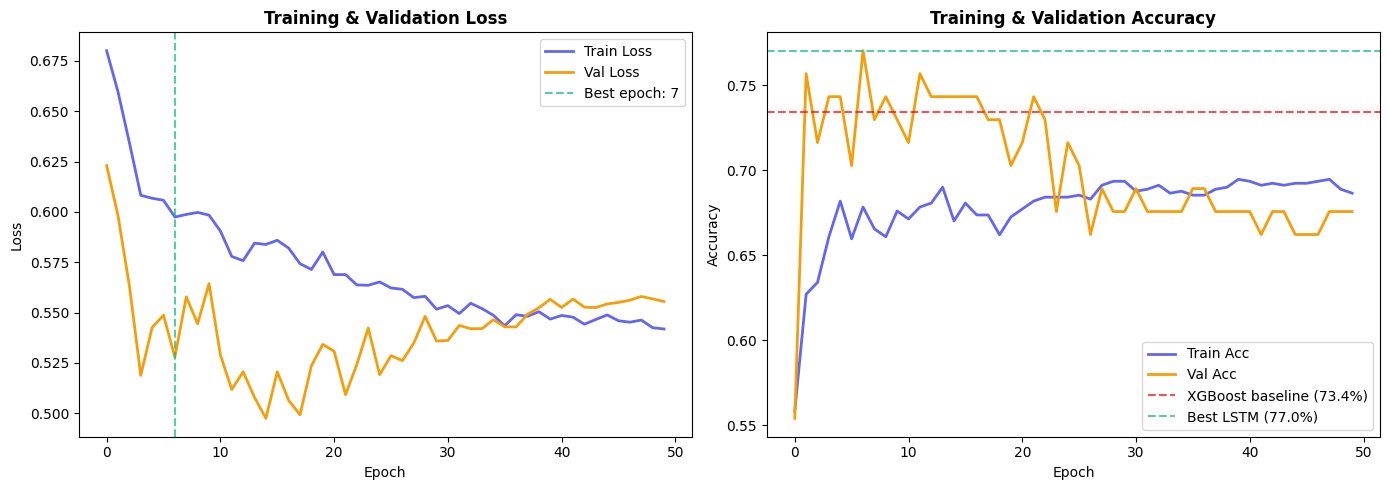

Training curves saved!


In [7]:
model.load_state_dict(best_model_state)
model.eval()


all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        probs, _ = model(X_batch)
        preds = (probs > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_auc = roc_auc_score(all_labels, all_probs)

print("=== LSTM-ATTENTION RESULTS ===")
print(f"Test Accuracy: {test_acc*100:.1f}%")
print(f"Test AUC-ROC:  {test_auc:.4f}")
print(f"Best Val Acc:  {best_val_acc*100:.1f}%")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, color='#6366F1', label='Train Loss', linewidth=2)
axes[0].plot(val_losses, color='#F59E0B', label='Val Loss', linewidth=2)
axes[0].axvline(val_accs.index(max(val_accs)), color='#10B981', 
                linestyle='--', alpha=0.7, label=f'Best epoch: {val_accs.index(max(val_accs))+1}')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(train_accs, color='#6366F1', label='Train Acc', linewidth=2)
axes[1].plot(val_accs, color='#F59E0B', label='Val Acc', linewidth=2)
axes[1].axhline(0.734, color='red', linestyle='--', alpha=0.7, label='XGBoost baseline (73.4%)')
axes[1].axhline(max(val_accs), color='#10B981', linestyle='--', 
                alpha=0.7, label=f'Best LSTM ({max(val_accs)*100:.1f}%)')
axes[1].set_title('Training & Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/08_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved!")

In [8]:
player_dna = pd.read_csv('../data/player_dna.csv')
player_dna['date'] = pd.to_datetime(player_dna['date'])

def build_enhanced_sequences(master_df, match_features_df, player_dna_df):
    sequences = []
    labels = []
    
    dna_features = ['career_avg', 'avg_last5', 'form_score', 
                    'consistency', 'boundary_rate', 'high_pressure_avg']
    
    for _, match in match_features_df.iterrows():
        mid = match['matchId']
        match_date = match['date']
        match_data = master_df[master_df['matchId'] == mid]
        first_inn = match_data[match_data['inning'] == 1]
        
        if len(first_inn) == 0:
            continue
        
        # Get top 4 batsmen for this innings
        top_batsmen = (first_inn[first_inn['is_wide']==0]
                      .groupby('batsman')['batsman_runs']
                      .sum().nlargest(4).index.tolist())
        
        # Get their DNA vectors 
        team_dna = []
        for batsman in top_batsmen:
            dna = player_dna_df[
                (player_dna_df['batsman'] == batsman) & 
                (player_dna_df['date'] < match_date)
            ].tail(1)
            
            if len(dna) > 0:
                team_dna.append(dna[dna_features].values[0])
            else:
                team_dna.append([0] * len(dna_features))
        
        # Pad to always have 4 batsmen
        while len(team_dna) < 4:
            team_dna.append([0] * len(dna_features))
        
        # Average DNA across top 4 batsmen
        avg_dna = np.mean(team_dna[:4], axis=0)
        
        # Build over sequence with DNA appended
        over_seq = []
        for over_num in range(1, 21):
            over_data = first_inn[first_inn['over'] == over_num]
            
            if len(over_data) == 0:
                over_features = [0] * 7
            else:
                runs = over_data['total_runs'].sum()
                wickets = over_data['is_wicket'].sum()
                balls = len(over_data[over_data['is_wide'] == 0])
                boundaries = (over_data['batsman_runs'].isin([4, 6])).sum()
                dot_balls = (over_data['total_runs'] == 0).sum()
                wides = over_data['is_wide'].sum()
                run_rate = runs / max(balls/6, 0.1)
                over_features = [runs, wickets, boundaries, 
                                 dot_balls, wides, run_rate, over_num/20]
            
            # Concatenate over features + team DNA
            over_seq.append(over_features + avg_dna.tolist())
        
        sequences.append(over_seq)
        labels.append(match['team1_won'])
    
    return np.array(sequences, dtype=np.float32), np.array(labels, dtype=np.float32)

print("Building enhanced sequences with Player DNA...")
X_enhanced, y_enhanced = build_enhanced_sequences(master, match_features, player_dna)
print(f"Enhanced sequences built!")
print(f"Shape: {X_enhanced.shape} → (matches, overs, over_features + dna_features)")
print(f"Features per timestep: 7 over features + 6 DNA features = 13")

Building enhanced sequences with Player DNA...
Enhanced sequences built!
Shape: (1146, 20, 13) → (matches, overs, over_features + dna_features)
Features per timestep: 7 over features + 6 DNA features = 13


In [9]:
X_train_e = X_enhanced[train_idx]
y_train_e = y_enhanced[train_idx]
X_val_e = X_enhanced[val_idx]
y_val_e = y_enhanced[val_idx]
X_test_e = X_enhanced[test_idx]
y_test_e = y_enhanced[test_idx]

# Scale
scaler_e = StandardScaler()
X_train_e_scaled = scaler_e.fit_transform(X_train_e.reshape(-1, 13)).reshape(-1, 20, 13)
X_val_e_scaled = scaler_e.transform(X_val_e.reshape(-1, 13)).reshape(-1, 20, 13)
X_test_e_scaled = scaler_e.transform(X_test_e.reshape(-1, 13)).reshape(-1, 20, 13)

# New DataLoaders
train_loader_e = DataLoader(IPLDataset(X_train_e_scaled, y_train_e), batch_size=32, shuffle=True)
val_loader_e = DataLoader(IPLDataset(X_val_e_scaled, y_val_e), batch_size=32, shuffle=False)
test_loader_e = DataLoader(IPLDataset(X_test_e_scaled, y_test_e), batch_size=32, shuffle=False)

# New model with input_size=13
model_e = IPLLSTMModel(input_size=13, hidden_size=128, num_layers=2, dropout=0.3).to(device)
criterion_e = nn.BCELoss()
optimizer_e = torch.optim.Adam(model_e.parameters(), lr=0.001)
scheduler_e = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_e, patience=5, factor=0.5)

train_losses_e, val_losses_e = [], []
train_accs_e, val_accs_e = [], []
best_val_acc_e = 0
best_model_state_e = None

EPOCHS = 60
print("Training enhanced LSTM...")
print("-" * 50)

for epoch in range(EPOCHS):
    model_e.train()
    train_loss, train_correct = 0, 0
    
    for X_batch, y_batch in train_loader_e:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_e.zero_grad()
        preds, _ = model_e(X_batch)
        loss = criterion_e(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_e.parameters(), 1.0)
        optimizer_e.step()
        train_loss += loss.item()
        train_correct += ((preds > 0.5) == y_batch).sum().item()
    
    model_e.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader_e:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds, _ = model_e(X_batch)
            loss = criterion_e(preds, y_batch)
            val_loss += loss.item()
            val_correct += ((preds > 0.5) == y_batch).sum().item()
    
    train_loss_avg = train_loss / len(train_loader_e)
    val_loss_avg = val_loss / len(val_loader_e)
    train_acc = train_correct / len(train_loader_e.dataset)
    val_acc = val_correct / len(val_loader_e.dataset)
    
    train_losses_e.append(train_loss_avg)
    val_losses_e.append(val_loss_avg)
    train_accs_e.append(train_acc)
    val_accs_e.append(val_acc)
    
    if val_acc > best_val_acc_e:
        best_val_acc_e = val_acc
        best_model_state_e = model_e.state_dict().copy()
    
    scheduler_e.step(val_loss_avg)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc*100:.1f}% | "
              f"Val Loss: {val_loss_avg:.4f} | Val Acc: {val_acc*100:.1f}%")

print(f"\nTraining complete! Best Val Accuracy: {best_val_acc_e*100:.1f}%")

Training enhanced LSTM...
--------------------------------------------------
Epoch  10/60 | Train Loss: 0.5866 | Train Acc: 66.8% | Val Loss: 0.5407 | Val Acc: 71.6%
Epoch  20/60 | Train Loss: 0.5223 | Train Acc: 71.3% | Val Loss: 0.5784 | Val Acc: 63.5%
Epoch  30/60 | Train Loss: 0.4418 | Train Acc: 76.9% | Val Loss: 0.7067 | Val Acc: 59.5%
Epoch  40/60 | Train Loss: 0.3962 | Train Acc: 79.7% | Val Loss: 0.7723 | Val Acc: 58.1%
Epoch  50/60 | Train Loss: 0.3907 | Train Acc: 79.8% | Val Loss: 0.8133 | Val Acc: 56.8%
Epoch  60/60 | Train Loss: 0.3890 | Train Acc: 79.4% | Val Loss: 0.8178 | Val Acc: 56.8%

Training complete! Best Val Accuracy: 75.7%


In [10]:
model_e.load_state_dict(best_model_state_e)
model_e.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader_e:
        X_batch = X_batch.to(device)
        probs, _ = model_e(X_batch)
        preds = (probs > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc_e = accuracy_score(all_labels, all_preds)
test_auc_e = roc_auc_score(all_labels, all_probs)

print("=== ENHANCED LSTM RESULTS ===")
print(f"Best Val Accuracy: {best_val_acc_e*100:.1f}%")
print(f"Test Accuracy:     {test_acc_e*100:.1f}%")
print(f"Test AUC-ROC:      {test_auc_e:.4f}")

# Final comparison table
print("\n=== FULL MODEL COMPARISON ===")
print(f"{'Model':<25} {'Test Acc':>10} {'Test AUC':>10}")
print("-" * 47)
print(f"{'Logistic Regression':<25} {'73.4%':>10} {'0.7732':>10}")
print(f"{'Random Forest':<25} {'70.6%':>10} {'0.7829':>10}")
print(f"{'XGBoost':<25} {'73.4%':>10} {'0.7750':>10}")
print(f"{'LSTM (basic)':<25} {'67.3%':>10} {'0.7683':>10}")
print(f"{'LSTM + Player DNA':<25} {f'{test_acc_e*100:.1f}%':>10} {f'{test_auc_e:.4f}':>10}")

=== ENHANCED LSTM RESULTS ===
Best Val Accuracy: 75.7%
Test Accuracy:     62.6%
Test AUC-ROC:      0.7081

=== FULL MODEL COMPARISON ===
Model                       Test Acc   Test AUC
-----------------------------------------------
Logistic Regression            73.4%     0.7732
Random Forest                  70.6%     0.7829
XGBoost                        73.4%     0.7750
LSTM (basic)                   67.3%     0.7683
LSTM + Player DNA              62.6%     0.7081


In [11]:
import pickle
import os

# Save enhanced LSTM
torch.save(best_model_state_e, '../models/lstm_attention.pt')
torch.save(best_model_state, '../models/lstm_basic.pt')

# Save scalers
with open('../models/scaler_enhanced.pkl', 'wb') as f:
    pickle.dump(scaler_e, f)

# Save sequences for ensemble use later
np.save('../data/X_enhanced.npy', X_enhanced)
np.save('../data/y_enhanced.npy', y_enhanced)
np.save('../data/X_seq.npy', X_seq)
np.save('../data/y_seq.npy', y_seq)

print("All models and data saved!")



All models and data saved!
